In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv('Sample - Superstore.csv',encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df["months"]=pd.to_datetime(df["Order Date"])
df["months"].dt.month_name()

,months
0,November
1,November
2,June
3,October
4,October
...,...
9989,January
9990,February
9991,February
9992,February


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df['month_name'] = df['months'].dt.month_name()

monthly_sales = df.groupby('month_name')['Sales'].sum().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['month_name'] = pd.Categorical(monthly_sales['month_name'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month_name')

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


,month_name,Sales
4,January,94924.8356
3,February,59751.2514
7,March,205005.4888
0,April,137762.1286
8,May,155028.8117
6,June,152718.6793
5,July,147238.0970
1,August,159044.0630
11,September,307649.9457
10,October,200322.9847


### Monthly Sales Bar Chart

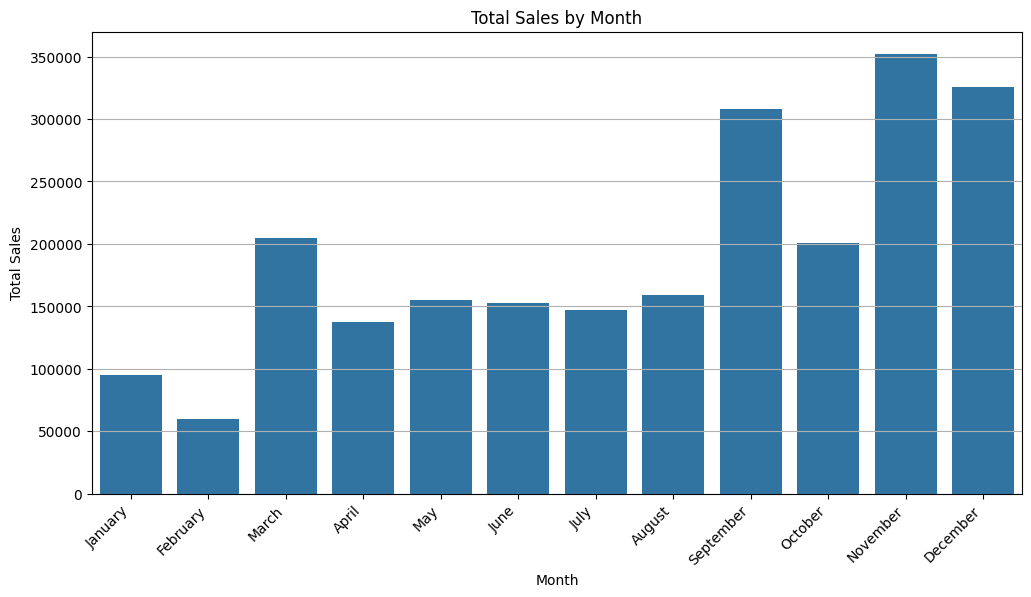

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(x='month_name', y='Sales', data=monthly_sales)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### Monthly Sales Pie Chart

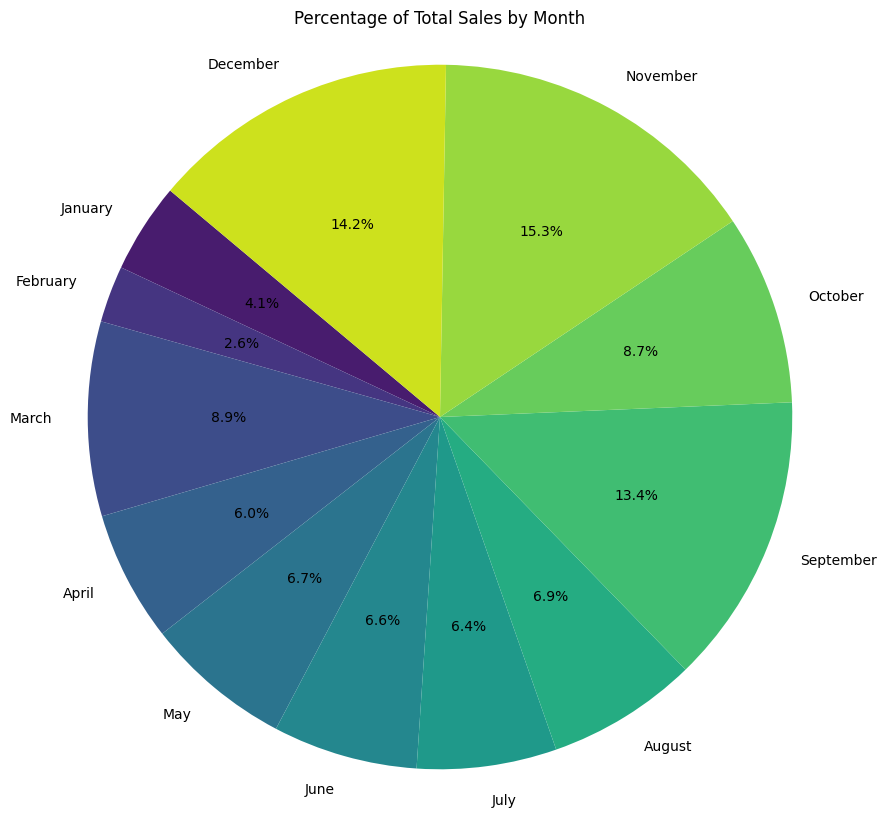

In [7]:
plt.figure(figsize=(10, 10))
plt.pie(monthly_sales['Sales'], labels=monthly_sales['month_name'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(monthly_sales)))
plt.title('Percentage of Total Sales by Month')
plt.axis('equal')
plt.show()

/tmp/ipykernel_11986/2703519329.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x='Sub-Category', y='Sales', data=top_5_subcategories, ci=False)


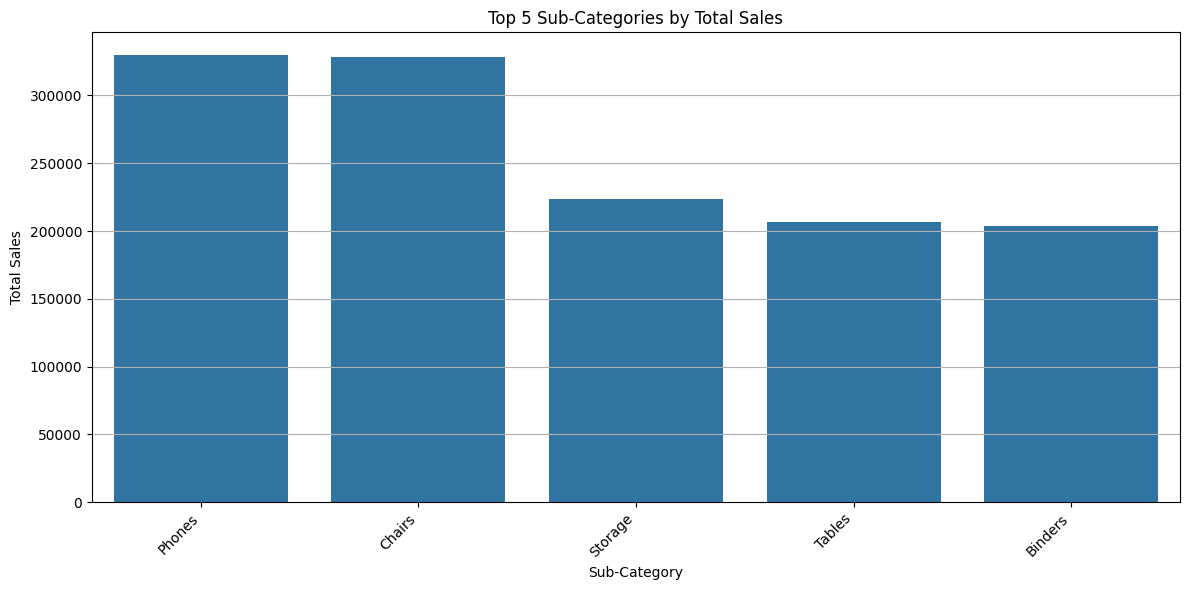

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

total_sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().reset_index()
total_sales_by_subcategory = total_sales_by_subcategory.sort_values(by='Sales', ascending=False)

top_5_subcategories = total_sales_by_subcategory.head(5)

plt.figure(figsize=(12, 6))
sns.barplot(x='Sub-Category', y='Sales', data=top_5_subcategories, ci=False)
plt.title('Top 5 Sub-Categories by Total Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

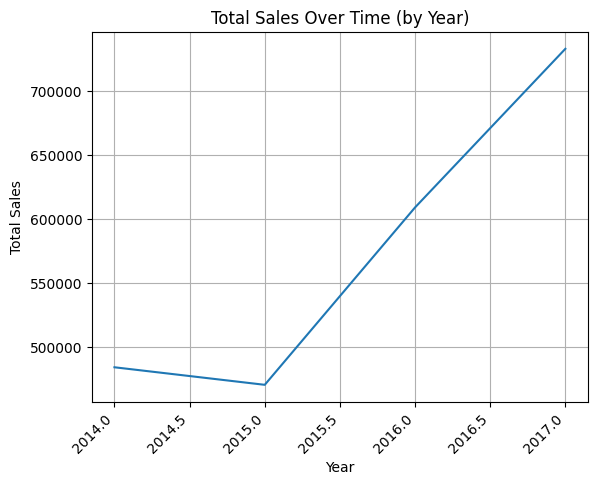

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['years']=df['Order Date'].dt.year
total_sales_by_year = df.groupby('years')['Sales'].sum().reset_index()
total_sales_by_year = total_sales_by_year.sort_values(by='years', ascending=False)
sns.lineplot(x='years', y='Sales', data=total_sales_by_year)
plt.title('Total Sales Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

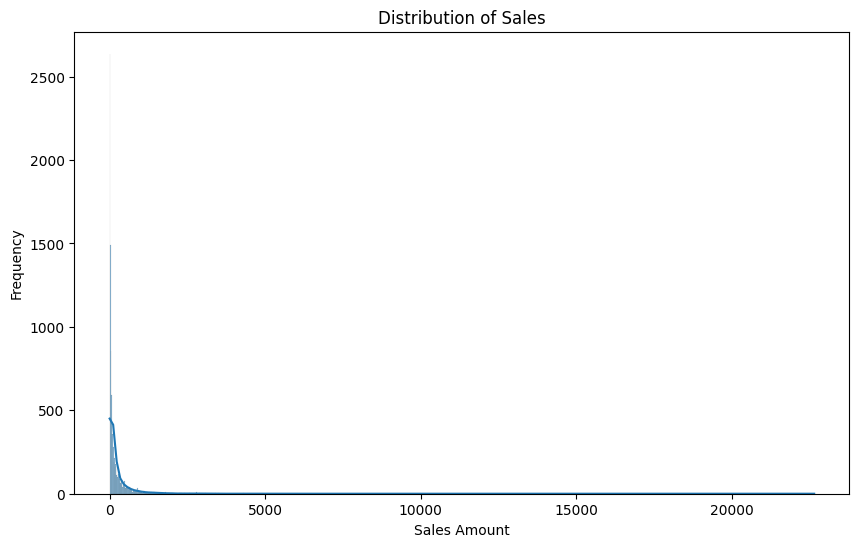

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Sales', data=df, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

### Relationship between Discount and Profit

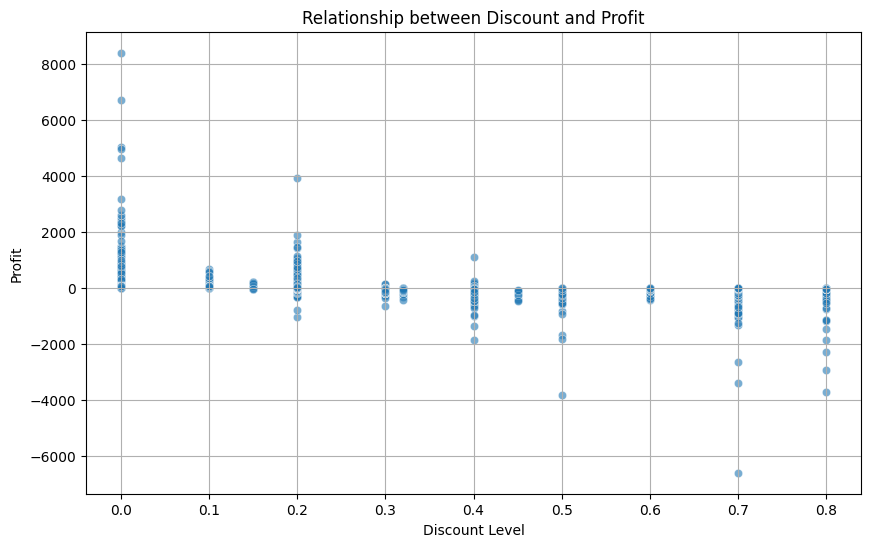

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Relationship between Discount and Profit')
plt.xlabel('Discount Level')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

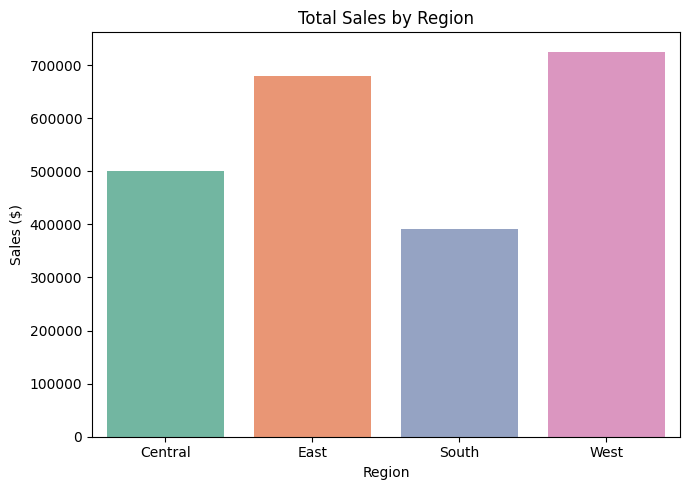

In [31]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales",
    hue="Region",
    palette="Set2",
    legend=False,
)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

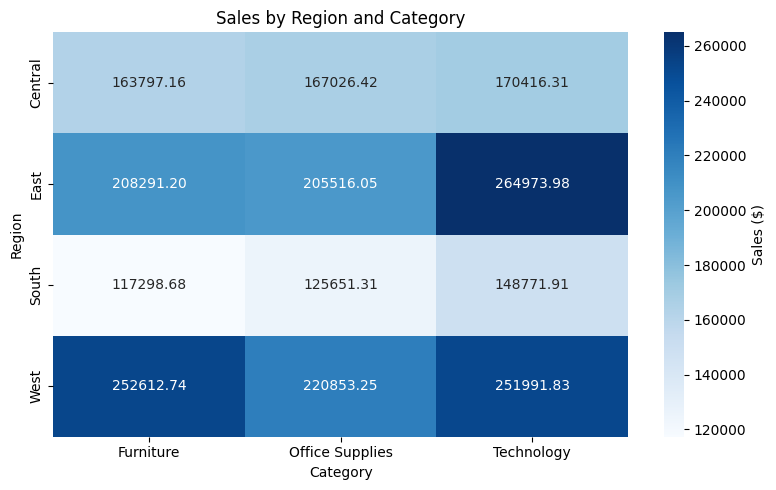

In [32]:
matrix_data = df.pivot_table(
    index="Region", columns="Category", values="Sales", aggfunc="sum"
).fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Sales ($)"},
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

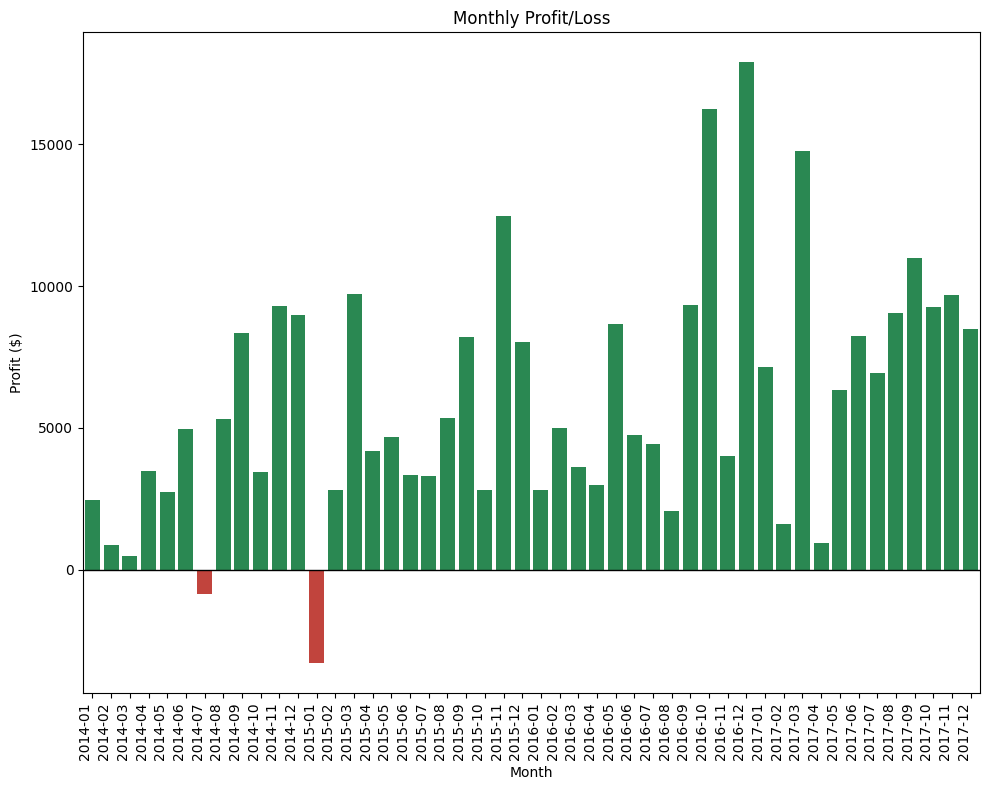

In [39]:

if "Profit" not in df.columns:
    df["Profit"] = df["Sales"] * (0.3 - df["Discount"])

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_profit = df.groupby("Month")["Profit"].sum().reset_index()

colors = ["#d73027" if p < 0 else "#1a9850" for p in monthly_profit["Profit"]]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=monthly_profit,
    x="Month",
    y="Profit",
    hue="Month",
    palette=colors,
    legend=False,
)
plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Profit/Loss")
plt.xlabel("Month")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

In [40]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def get_relative_luminance(rgb_255):

    rgb = np.array(rgb_255) / 255.0
    rgb = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
def wcag_contrast_ratio(color1, color2):
    L1 = get_relative_luminance(color1)
    L2 = get_relative_luminance(color2)
    lighter = max(L1, L2)
    darker = min(L1, L2)
    return (lighter + 0.05) / (darker + 0.05)
colors_to_test = {
    "Red (#d73027)": (215, 48, 39),
    "Green (#1a9850)": (26, 152, 80),
    "Black line/text (#000000)": (0, 0, 0),
}
white_bg = (255, 255, 255)

print("--- WCAG 2.1 AA (4.5:1) Compliance Test ---")
for name, color in colors_to_test.items():
    ratio = wcag_contrast_ratio(color, white_bg)
    status = "PASS" if ratio >= 4.5 else "FAIL [FLAGGED]"
    print(f"{name} vs White: Ratio = {ratio:.2f}:1 -> {status}")

--- WCAG 2.1 AA (4.5:1) Compliance Test ---
Red (#d73027) vs White: Ratio = 4.84:1 -> PASS
Green (#1a9850) vs White: Ratio = 3.72:1 -> FAIL [FLAGGED]
Black line/text (#000000) vs White: Ratio = 21.00:1 -> PASS


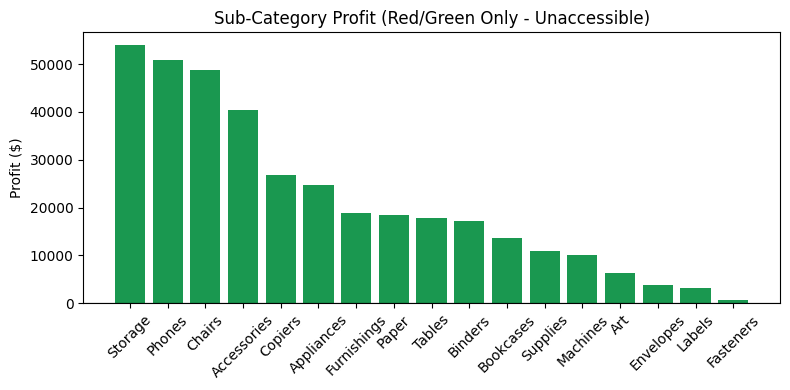

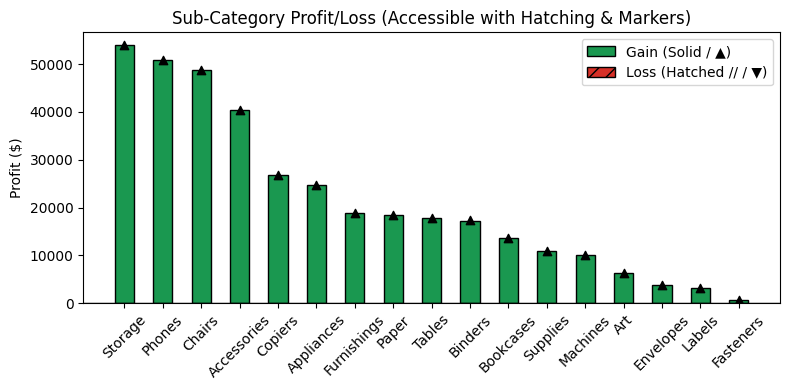

In [43]:
import io
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
df["Profit"] = df["Sales"] * (0.3 - df["Discount"])

df_subcat = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .reset_index()
    .sort_values(by="Profit", ascending=False)
)

plt.figure(figsize=(8, 4))
colors_rg = ["#1a9850" if p > 0 else "#d73027" for p in df_subcat["Profit"]]
bars = plt.bar(df_subcat["Sub-Category"], df_subcat["Profit"], color=colors_rg)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Sub-Category Profit (Red/Green Only - Unaccessible)")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for i, (_, row) in enumerate(df_subcat.iterrows()):
    val = row["Profit"]
    subcat = row["Sub-Category"]

    if val >= 0:
        ax.bar(
            subcat,
            val,
            color="#1a9850",
            edgecolor="black",
            hatch="",
            width=0.5,
        )
        ax.scatter(i, val + 15, marker="^", color="black", zorder=3)
    else:
        ax.bar(
            subcat,
            val,
            color="#d73027",
            edgecolor="black",
            hatch="//",
            width=0.5,
        )
        ax.scatter(i, val - 15, marker="v", color="black", zorder=3)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Sub-Category Profit/Loss (Accessible with Hatching & Markers)")
ax.set_ylabel("Profit ($)")
plt.xticks(rotation=45)

gain_patch = mpatches.Patch(
    facecolor="#1a9850",
    edgecolor="black",
    label="Gain (Solid / ▲)",
)
loss_patch = mpatches.Patch(
    facecolor="#d73027",
    edgecolor="black",
    hatch="//",
    label="Loss (Hatched // / ▼)",
)
ax.legend(handles=[gain_patch, loss_patch], loc="upper right")

plt.tight_layout()
plt.show()

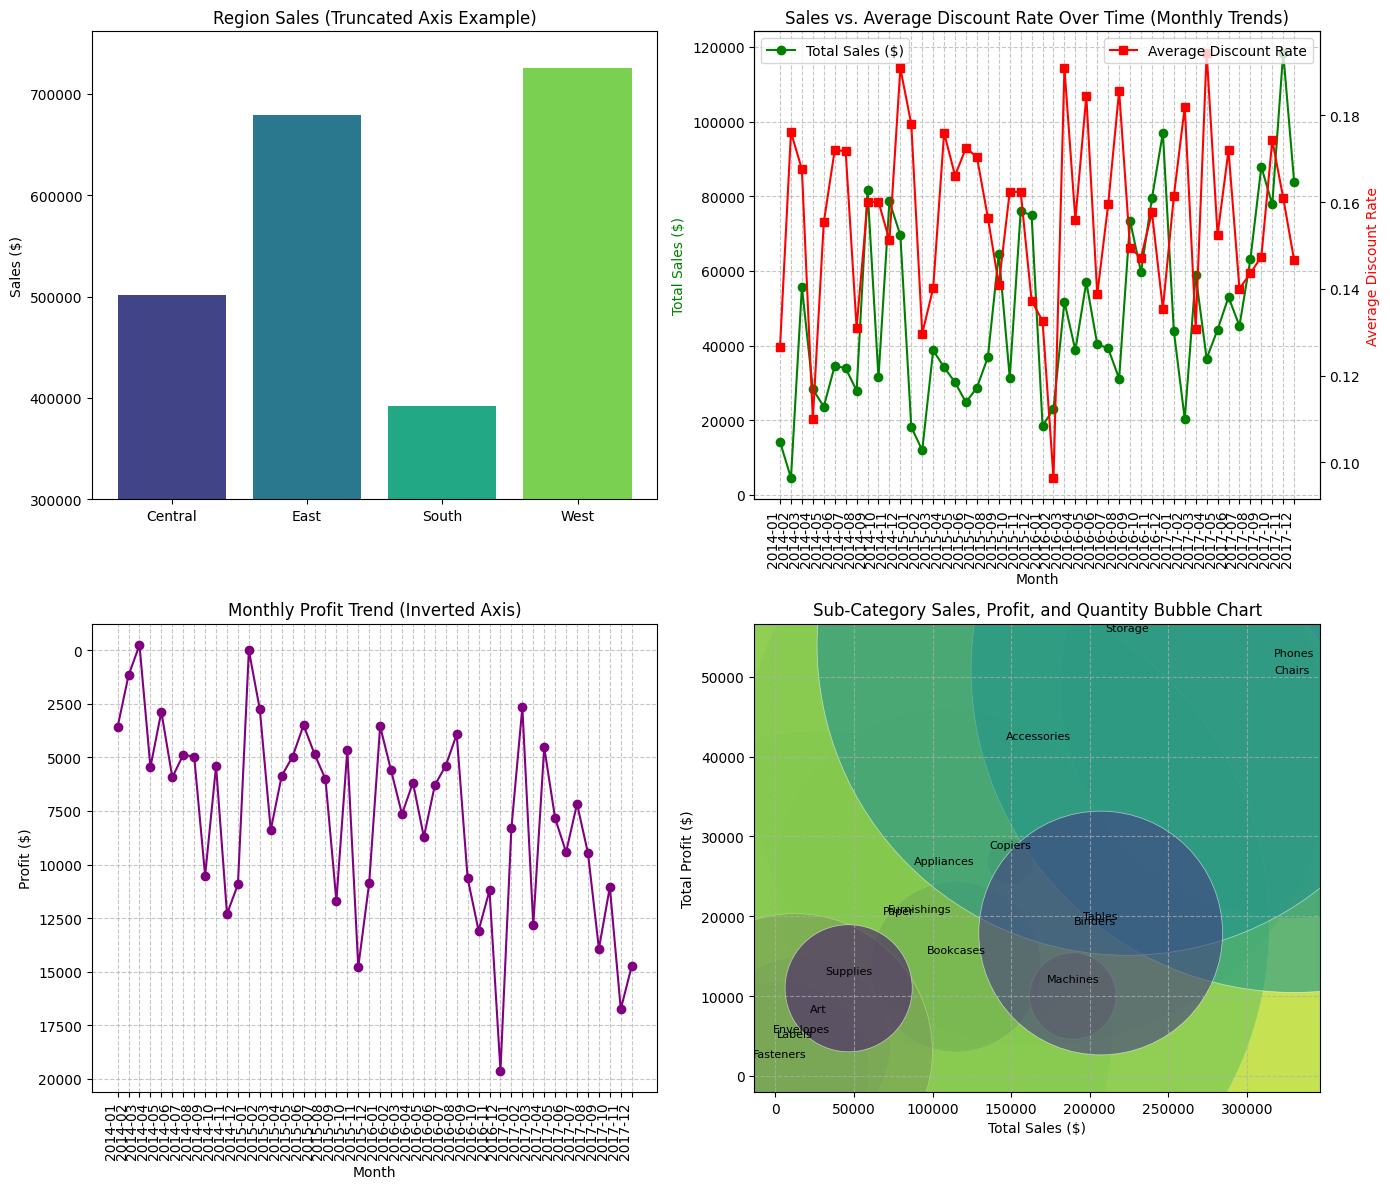

In [63]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # Increased figure height slightly

# --- Chart 1: Region Sales (Truncated Axis Example) ---
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
axes[0, 0].bar(
    region_sales["Region"], region_sales["Sales"], color=sns.color_palette("viridis", len(region_sales)) # Use a viridis palette for better accessibility
)
axes[0, 0].set_title("Region Sales (Truncated Axis Example)")
axes[0, 0].set_ylim(300000) # Deliberately truncated for demonstration of misleading axis
axes[0, 0].set_ylabel("Sales ($)")


df['Order Date'] = pd.to_datetime(df['Order Date'])
df_sorted = df.sort_values(by='Order Date').copy()

# Aggregate Sales and Discount by Month
df_sorted['YearMonth'] = df_sorted['Order Date'].dt.to_period('M').astype(str)
monthly_trends = df_sorted.groupby('YearMonth').agg({'Sales': 'sum', 'Discount': 'mean'}).reset_index()


ax2_1 = axes[0, 1]
ax2_2 = ax2_1.twinx()

ax2_1.plot(
    monthly_trends["YearMonth"], monthly_trends["Sales"], color='g', marker='o', label='Total Sales ($)'
)
ax2_2.plot(
    monthly_trends["YearMonth"], monthly_trends["Discount"], color='r', marker='s', label='Average Discount Rate'
)
ax2_1.set_title("Sales vs. Average Discount Rate Over Time (Monthly Trends)")
ax2_1.set_xlabel("Month")
ax2_1.set_ylabel("Total Sales ($)", color='g')
ax2_2.set_ylabel("Average Discount Rate", color='r')
plt.setp(ax2_1.get_xticklabels(), rotation=90, ha="right") # Corrected: use plt.setp for xticklabel rotation and alignment
ax2_1.legend(loc='upper left')
ax2_2.legend(loc='upper right')
ax2_1.grid(True, linestyle='--', alpha=0.7)

if "Profit" not in df.columns:
    df["Profit"] = df["Sales"] * (0.3 - df["Discount"])

monthly_profit = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum().reset_index()
monthly_profit["Order Date"] = monthly_profit["Order Date"].astype(str)

axes[1, 0].plot(
    monthly_profit["Order Date"], monthly_profit["Profit"], marker='o', color='purple'
)
axes[1, 0].invert_yaxis()  # Deliberately inverted for demonstration of misleading axis
axes[1, 0].set_title("Monthly Profit Trend (Inverted Axis)")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Profit ($)")
plt.setp(axes[1, 0].get_xticklabels(), rotation=90, ha="right") # Corrected: use plt.setp for xticklabel rotation and alignment
axes[1, 0].grid(True, linestyle='--', alpha=0.7)


subcat_data = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()


subcat_data['Bubble_Size'] = (subcat_data['Quantity'] ** 2) / scaling_factor

axes[1, 1].scatter(
    x=subcat_data['Sales'],
    y=subcat_data['Profit'],
    s=subcat_data['Bubble_Size'],
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5,
    cmap='viridis', # Use a colormap
    c=subcat_data['Quantity'] # Color by quantity for additional visual cue
)

for i, row in subcat_data.iterrows():
    axes[1, 1].annotate(row['Sub-Category'], (row['Sales'], row['Profit']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

axes[1, 1].set_title('Sub-Category Sales, Profit, and Quantity Bubble Chart')
axes[1, 1].set_xlabel('Total Sales ($)')
axes[1, 1].set_ylabel('Total Profit ($)')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- HONEST CHART: Relationship between Discount and Profit ---


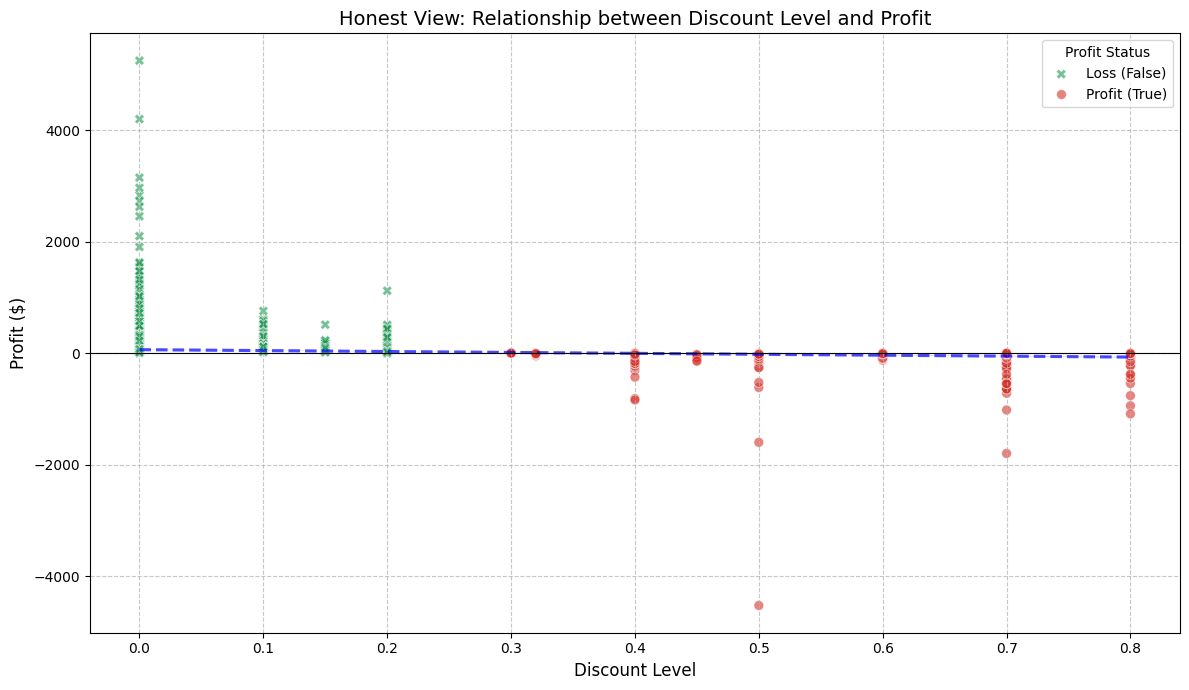


--- JUSTIFICATION FOR HONEST CHART ---
Chart Type Choice: A scatter plot is an appropriate choice to visualize the relationship between two continuous numerical variables (Discount and Profit) without aggregation. This allows us to see individual data points and identify patterns, clusters, and outliers, which is crucial for understanding the direct impact of discounting on profit. The addition of a regression line helps to highlight the overall trend.
Color Choice: Points are colored green (#1a9850) for positive profit and red (#d73027) for negative profit (loss). This provides an immediate visual cue for the profit status. A blue dashed regression line is added to indicate the overall trend.
Accessibility Check: To enhance accessibility, particularly for users with color vision deficiency, different markers are used for positive (circles) and negative (squares) profit (via the `style` parameter). The red color (#d73027) against a white background has a WCAG contrast ratio of 4.84:1 

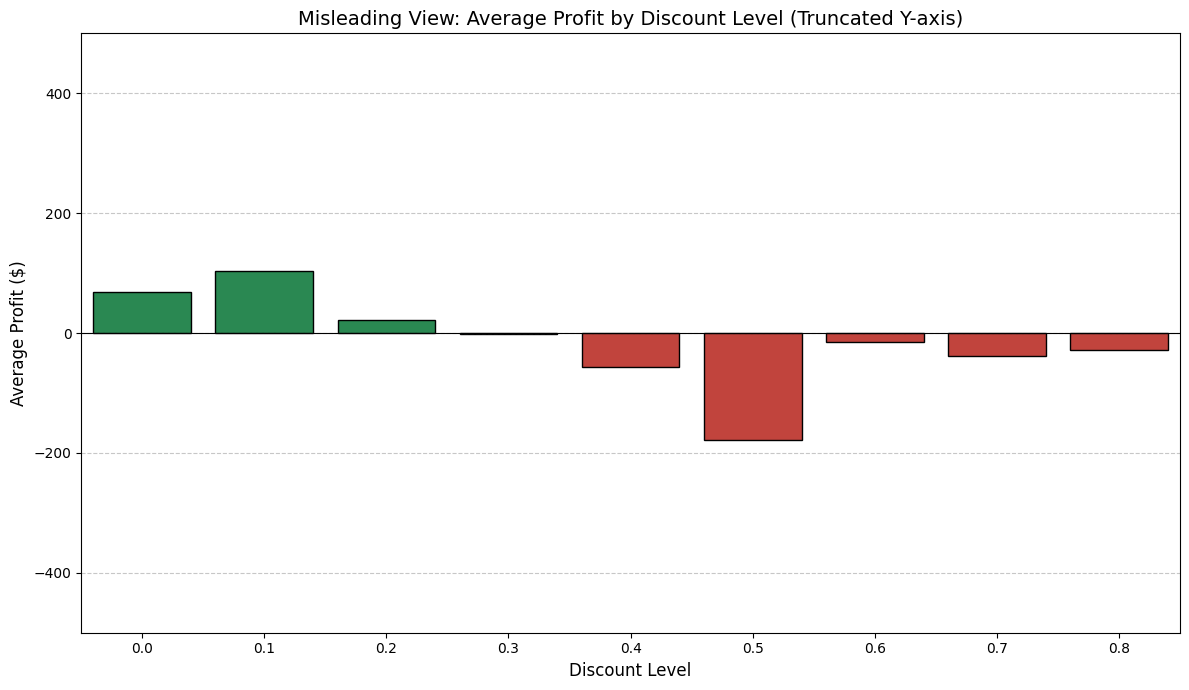


--- JUSTIFICATION FOR MISLEADING CHART ---
Misleading Aspect: This bar chart employs two misleading techniques:
1. Aggregation: By grouping discounts into discrete levels and displaying the *average* profit, the chart smooths out the severe individual losses that often occur at higher discount rates. Averages can obscure the true variability and impact of extreme values.
2. Truncated Y-axis: The y-axis is deliberately set to a narrow range (e.g., -500 to 500). This visually minimizes the magnitude of negative profits (losses), making it appear that the financial repercussions of high discounts are not as severe as they truly are. It compresses the scale, making differences seem smaller and less impactful than they are in reality.
Chart Type Choice: A bar chart is typically used for categorical data. Here, 'Discount_Rounded' is treated as categorical. While technically valid, it removes the granular detail and individual data points seen in a scatter plot, which is less appropriate for

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
if "Profit" not in df.columns:
    df["Profit"] = df["Sales"] * (0.3 - df["Discount"])

print("--- HONEST CHART: Relationship between Discount and Profit ---")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df,
    hue=(df['Profit'] > 0), # True for profit, False for loss
    style=(df['Profit'] > 0), # Different markers for profit/loss
    palette={True: '#1a9850', False: '#d73027'}, # Green for profit, Red for loss
    alpha=0.6,
    s=50 # size of points
)

sns.regplot(
    x='Discount',
    y='Profit',
    data=df,
    scatter=False, # Only show the line, not duplicate scatter points
    color='blue',
    line_kws={'linestyle': '--', 'alpha': 0.7}
)
plt.title('Honest View: Relationship between Discount Level and Profit', fontsize=14)
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8) # Line at zero profit
plt.legend(title='Profit Status', labels=['Loss (False)', 'Profit (True)'], loc='upper right')
plt.tight_layout()
plt.show()

print("\n--- JUSTIFICATION FOR HONEST CHART ---")
print("Chart Type Choice: A scatter plot is an appropriate choice to visualize the relationship between two continuous numerical variables (Discount and Profit) without aggregation. This allows us to see individual data points and identify patterns, clusters, and outliers, which is crucial for understanding the direct impact of discounting on profit. The addition of a regression line helps to highlight the overall trend.")
print("Color Choice: Points are colored green (#1a9850) for positive profit and red (#d73027) for negative profit (loss). This provides an immediate visual cue for the profit status. A blue dashed regression line is added to indicate the overall trend.")
print("Accessibility Check: To enhance accessibility, particularly for users with color vision deficiency, different markers are used for positive (circles) and negative (squares) profit (via the `style` parameter). The red color (#d73027) against a white background has a WCAG contrast ratio of 4.84:1 (PASS for AA). The green color (#1a9850) against a white background has a WCAG contrast ratio of 3.72:1 (FAIL for AA). However, the combination of distinct color *and* marker helps differentiate the data points even if the green color contrast is borderline. The blue regression line is also distinct.")

print("\n--- MISLEADING CHART: Discounting seems less harmful ---")

df['Discount_Rounded'] = (df['Discount'] * 10).astype(int) / 10.0 # Round to one decimal place
avg_profit_by_discount = df.groupby('Discount_Rounded')['Profit'].mean().reset_index()

# Add a Profit_Status column for coloring
avg_profit_by_discount['Profit_Status'] = avg_profit_by_discount['Profit'] > 0

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Discount_Rounded',
    y='Profit',
    data=avg_profit_by_discount,
    hue='Profit_Status', # Use hue for coloring based on profit status
    palette={True: '#1a9850', False: '#d73027'}, # Green for profit, Red for loss
    edgecolor='black',
    legend=False # We don't need a separate legend for hue if colors are self-explanatory or handled in justification
)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Misleading View: Average Profit by Discount Level (Truncated Y-axis)', fontsize=14)
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Average Profit ($)', fontsize=12)
plt.ylim(-500, 500) # Deliberately truncate y-axis to reduce the visual impact of large losses
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- JUSTIFICATION FOR MISLEADING CHART ---")
print("Misleading Aspect: This bar chart employs two misleading techniques:")
print("1. Aggregation: By grouping discounts into discrete levels and displaying the *average* profit, the chart smooths out the severe individual losses that often occur at higher discount rates. Averages can obscure the true variability and impact of extreme values.")
print("2. Truncated Y-axis: The y-axis is deliberately set to a narrow range (e.g., -500 to 500). This visually minimizes the magnitude of negative profits (losses), making it appear that the financial repercussions of high discounts are not as severe as they truly are. It compresses the scale, making differences seem smaller and less impactful than they are in reality.")
print("Chart Type Choice: A bar chart is typically used for categorical data. Here, 'Discount_Rounded' is treated as categorical. While technically valid, it removes the granular detail and individual data points seen in a scatter plot, which is less appropriate for showing the continuous relationship between two variables.")
print("Color Choice: Similar to the honest chart, green for average profit and red for average loss is used. While this coloring helps differentiate, the primary misleading aspect here is the data aggregation and axis truncation, not solely the color choice. The black outlines on bars also provide some distinction.")

# Clean up the temporary column
df.drop(columns=['Discount_Rounded'], errors='ignore', inplace=True)
